In [1]:
import os
os.environ["OPENAI_API_KEY"] = "sk-proj-ORV1HwUGs8R8vWlaRYLdAzJfhxLH9NYWyb5GDGGm9Il4JLsPWQX5L1I8A9hR_Cbs1a0JWaPCtUdqvv5LRedP2mIWl8A"

In [2]:
!pip install langGraph

In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [4]:
class student_marks(TypedDict):
    marks1:int
    marks2:int
    percentage : float
    Grade : str
    Result : str

In [5]:
def Calculate_percentage(state : student_marks ) -> student_marks:
  marks_of_subject1 = state['marks1']
  marks_of_subject2 = state['marks2']
  total_marks = marks_of_subject1 + marks_of_subject2
  percentage = (total_marks/200)*100
  state['percentage'] = percentage
  return state

In [6]:
def label_grade(state : student_marks) -> student_marks:
  percentage = state['percentage']
  if percentage >= 75:
    state["Grade"] = 'A'
    state["Result"] = 'Pass'
  elif percentage >= 50:
    state["Grade"] = 'B'
    state["Result"] = 'Pass'
  elif percentage >= 25:
    state["Grade"] = 'C'
    state["Result"] = 'Pass'
  else:
    state["Grade"] = 'F'
    state["Result"] = 'Fail'
  return state


In [7]:
graph = StateGraph(student_marks)
graph.add_node("Calculate_percentage",Calculate_percentage)
graph.add_node("label_grade",label_grade)
graph.add_edge(START,"Calculate_percentage")
graph.add_edge("Calculate_percentage","label_grade")
graph.add_edge("label_grade",END)
workflow = graph.compile()

In [8]:
initial_state = {"marks1":80,"marks2":70}
final_state = workflow.invoke(initial_state)
print(final_state)

{'marks1': 80, 'marks2': 70, 'percentage': 75.0, 'Grade': 'A', 'Result': 'Pass'}


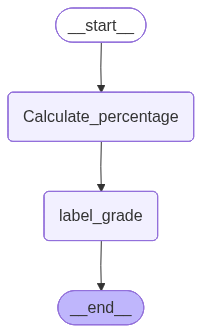

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())